# RandomForest Cirrhosis Optimized
Target: Cirrhosis_Status

In [13]:
!pip install -q xgboost

Loading: /content/drive/MyDrive/5/nafld2.csv
Loading: /content/drive/MyDrive/5/nwtco.csv
Loading: /content/drive/MyDrive/5/nafld1.csv

Dataset shape:
(421700, 21)
Index(['Unnamed: 0', 'id', 'days', 'test', 'value', 'seqno', 'instit',
       'histol', 'stage', 'study', 'rel', 'edrel', 'age', 'in.subcohort',
       'male', 'weight', 'height', 'bmi', 'case.id', 'futime', 'status'],
      dtype='object')

Target distribution:
status
0.0    420336
1.0      1364
Name: count, dtype: int64
Encoding: test
Encoding: in.subcohort

Training Random Forest...
Training finished

===== RESULTS =====
Accuracy: 0.9969172397438938
Precision: 0.9959376041951934
Recall: 0.9969172397438938
F1-score: 0.9959706026250124
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     84067
         1.0       0.60      0.14      0.23       273

    accuracy                           1.00     84340
   macro avg       0.80      0.57      0.61     84340
weighted avg       1.0

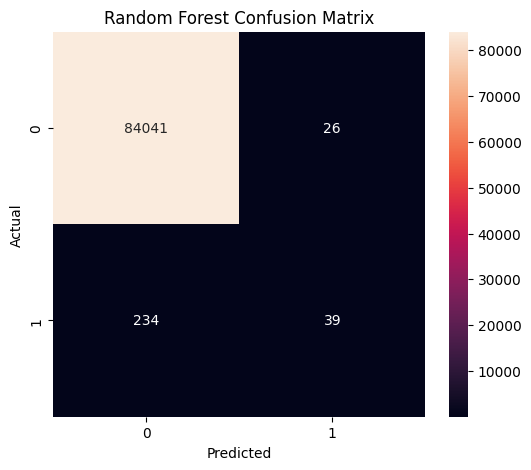


Model saved successfully


In [51]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib



# ==============================
# PATH
# ==============================

PROJECT_PATH = "/content/drive/MyDrive/5"


DATA_FOLDER = PROJECT_PATH


MODEL_FOLDER = PROJECT_PATH + "/models_RF"


RESULT_FOLDER = PROJECT_PATH + "/results_RF"



os.makedirs(
    MODEL_FOLDER,
    exist_ok=True
)


os.makedirs(
    RESULT_FOLDER,
    exist_ok=True
)



# ==============================
# LOAD CSV FILES
# ==============================

dataframes = []


for file in os.listdir(DATA_FOLDER):

    if file.endswith(".csv"):

        path = os.path.join(
            DATA_FOLDER,
            file
        )

        print("Loading:", path)


        df = pd.read_csv(path)

        dataframes.append(df)



data = pd.concat(
    dataframes,
    ignore_index=True
)



print("\nDataset shape:")
print(data.shape)



print(data.columns)



# ==============================
# CLEANING
# ==============================

# ==============================
# CLEANING CORRIGE
# ==============================

data.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
    inplace=True
)


for col in data.columns:


    if data[col].dtype == "object" or data[col].dtype == "bool":

        data[col] = data[col].fillna(
            "Unknown"
        )


    else:

        data[col] = data[col].fillna(
            data[col].median()
        )


# ==============================
# TARGET
# ==============================


TARGET = "status"



X = data.drop(
    columns=[
        TARGET,
        "source",
        "id",
        "case.id"
    ],
    errors="ignore"
)



y = data[TARGET]



print("\nTarget distribution:")
print(y.value_counts())



# ==============================
# ENCODING
# ==============================

# ==============================
# ENCODING CORRIGE
# ==============================

encoder_dict = {}


for col in X.columns:

    # Si la colonne contient des objets ou booléens
    if X[col].dtype == "object" or X[col].dtype == "bool":

        print("Encoding:", col)

        # convertir tout en texte
        X[col] = X[col].astype(str)


        encoder = LabelEncoder()


        X[col] = encoder.fit_transform(
            X[col]
        )


        encoder_dict[col] = encoder



# ==============================
# SPLIT
# ==============================


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



# ==============================
# RANDOM FOREST
# ==============================


model = RandomForestClassifier(

    n_estimators=200,

    max_depth=None,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"

)



print("\nTraining Random Forest...")


model.fit(

    X_train,

    y_train

)



print("Training finished")



# ==============================
# PREDICTION
# ==============================


y_pred = model.predict(
    X_test
)



# ==============================
# METRICS
# ==============================


accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)



print("\n===== RESULTS =====")

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)


print(
    classification_report(
        y_test,
        y_pred
    )
)



# ==============================
# CONFUSION MATRIX
# ==============================


cm = confusion_matrix(
    y_test,
    y_pred
)



plt.figure(
    figsize=(6,5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Random Forest Confusion Matrix"
)


plt.savefig(
    RESULT_FOLDER + "/confusion_matrix.png"
)


plt.show()



# ==============================
# FEATURE IMPORTANCE
# ==============================


importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance.sort_values(

    by="Importance",

    ascending=False

).to_csv(

    RESULT_FOLDER + "/feature_importance.csv",

    index=False

)



# ==============================
# SAVE MODEL
# ==============================


joblib.dump(

    model,

    MODEL_FOLDER + "/random_forest.pkl"

)


joblib.dump(

    encoder_dict,

    MODEL_FOLDER + "/encoders.pkl"

)



print("\nModel saved successfully")

In [49]:
!pip install scikit-learn joblib

In [45]:
!pip install lightgbm